In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

path="Visadataset.csv"
visa_df=pd.read_csv(path)
cat=visa_df.select_dtypes(include="object").columns
num=visa_df.select_dtypes(exclude="object").columns

In [2]:
# we have 2 columns
# continent and another columns is case_status
visa_df["continent"].value_counts()

continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64

In [3]:
visa_df["case_status"].value_counts()

case_status
Certified    17018
Denied        8462
Name: count, dtype: int64

In [4]:
# how many asia student are got certified
# how many asia students are not certified

In [7]:
con1=visa_df["continent"]=="Asia"
con2=visa_df["case_status"]=="Certified"
con=con1 & con2
len(visa_df[con])

11012

In [12]:
continent_label=visa_df["continent"].unique()
certified_list=[]
for i in continent_label:
    con1=visa_df["continent"]==i
    con2=visa_df["case_status"]=="Certified"
    con=con1&con2
    certified_list.append(len(visa_df[con]))
certified_list

[11012, 397, 2037, 2957, 493, 122]

In [13]:
continent_label=visa_df["continent"].unique()
denied_list=[]
for i in continent_label:
    con1=visa_df["continent"]==i
    con2=visa_df["case_status"]=="Denied"
    con=con1&con2
    denied_list.append(len(visa_df[con]))
denied_list

[5849, 154, 1255, 775, 359, 70]

In [15]:
pd.DataFrame(zip(certified_list,denied_list),columns=["Certified Count","Denied Count"],index=continent_label)

,Certified Count,Denied Count
Asia,11012,5849
Africa,397,154
North America,2037,1255
Europe,2957,775
South America,493,359
Oceania,122,70


In [18]:
con=visa_df["case_status"]=="Certified"
visa_df[con].groupby("continent").size()

continent
Africa             397
Asia             11012
Europe            2957
North America     2037
Oceania            122
South America      493
dtype: int64

In [23]:
col1=visa_df["continent"]
col2=visa_df["case_status"]
r1=pd.crosstab(col1,col2)
r1

case_status,Certified,Denied
continent,,
Africa,397,154
Asia,11012,5849
Europe,2957,775
North America,2037,1255
Oceania,122,70
South America,493,359


In [24]:
r2=pd.crosstab(col2,col1)
r2

continent,Africa,Asia,Europe,North America,Oceania,South America
case_status,,,,,,
Certified,397,11012,2957,2037,122,493
Denied,154,5849,775,1255,70,359


<Axes: xlabel='continent'>

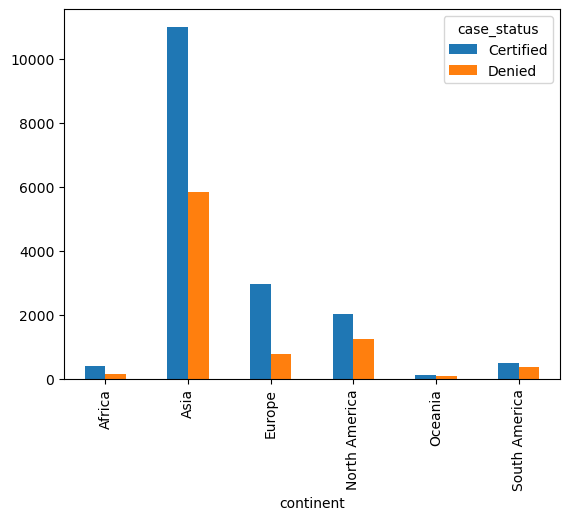

In [27]:
r1.plot(kind="bar")

<Axes: xlabel='case_status'>

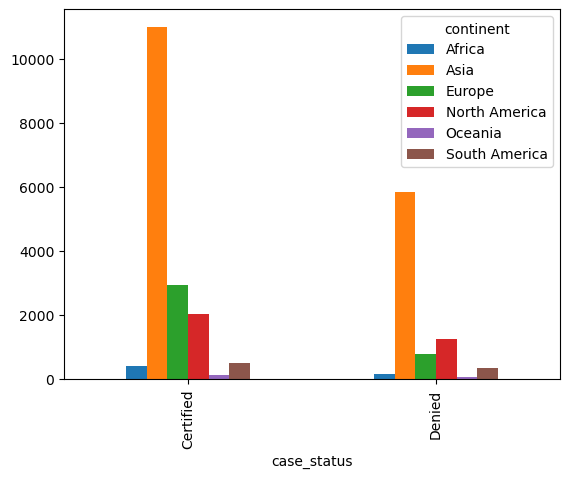

In [28]:
r2.plot(kind="bar")

In [29]:
# continent 
# education of employee
# case status

# there are 11k applicants are certified from asia 
# now i want to know there education of that 11k applicant

In [32]:
col1=visa_df["case_status"]
col2=visa_df["continent"]
col3=visa_df["education_of_employee"]
cols=[col2,col3]
pd.crosstab(col1,cols)

continent                 Africa                                      Asia  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
case_status                                                                  
Certified                     81        43          23      250       4407   
Denied                        62        11          43       38       2761   

continent                                                Europe            \
education_of_employee Doctorate High School Master's Bachelor's Doctorate   
case_status                                                                 
Certified                   780         676     5149       1040       788   
Denied                      143        1614     1331        259        58   

continent              ... North America             Oceania            \
education_of_employee  ...   High School Master's Bachelor's Doctorate   
case_status            ...                                               
Certified              ...           210      979         38        19   
Denied                 ...           191      429         28         3   

continent                                  South America            \
education_of_employee High School Master's    Bachelor's Doctorate   
case_status                                                          
Certified                      19       46           160        75   
Denied                         17       22           173        14   

continent                                   
education_of_employee High School Master's  
case_status                                 
Certified                      74      184  
Denied                         63      109  

[2 rows x 24 columns]

In [33]:
col1=visa_df["case_status"]
col2=visa_df["continent"]
col3=visa_df["education_of_employee"]
cols=[col1,col2]
pd.crosstab(col3,cols)

case_status           Certified                                     \
continent                Africa  Asia Europe North America Oceania   
education_of_employee                                                
Bachelor's                   81  4407   1040           641      38   
Doctorate                    43   780    788           207      19   
High School                  23   676    162           210      19   
Master's                    250  5149    967           979      46   

case_status                         Denied                                     \
continent             South America Africa  Asia Europe North America Oceania   
education_of_employee                                                           
Bachelor's                      160     62  2761    259           584      28   
Doctorate                        75     11   143     58            51       3   
High School                      74     43  1614    328           191      17   
Master's                        184     38  1331    130           429      22   

case_status                          
continent             South America  
education_of_employee                
Bachelor's                      173  
Doctorate                        14  
High School                      63  
Master's                        109

In [34]:
col1=visa_df["case_status"]
col2=visa_df["continent"]
col3=visa_df["education_of_employee"]
cols=[col1,col3]
pd.crosstab(col2,cols)

case_status            Certified                                    Denied  \
education_of_employee Bachelor's Doctorate High School Master's Bachelor's   
continent                                                                    
Africa                        81        43          23      250         62   
Asia                        4407       780         676     5149       2761   
Europe                      1040       788         162      967        259   
North America                641       207         210      979        584   
Oceania                       38        19          19       46         28   
South America                160        75          74      184        173   

case_status                                           
education_of_employee Doctorate High School Master's  
continent                                             
Africa                       11          43       38  
Asia                        143        1614     1331  
Europe                       58         328      130  
North America                51         191      429  
Oceania                       3          17       22  
South America                14          63      109